# Spatial Regression Models -Landslide-

Spatial regression of landslides in the northern colombian Andes.

In [112]:
import warnings
warnings.filterwarnings('ignore')

import libpysal
from pysal.model import spreg
from pysal.lib import weights
from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn

In [56]:
file="G:/My Drive/INVESTIGACION/POSDOC/GLM/landslides/PUNTOS_FINAL/PUNTOS_FINAL.shp"

In [57]:
db = gpd.read_file(file)

In [58]:
db.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6189 entries, 0 to 6188
Data columns (total 51 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID_Puntos  6189 non-null   int64   
 1   Id          6189 non-null   int64   
 2   FID_1       6189 non-null   int64   
 3   FID_punt_1  6189 non-null   int64   
 4   FID_Datos_  6189 non-null   int64   
 5   fid_        6189 non-null   int64   
 6   ID_CUENCA   6189 non-null   int64   
 7   Nombre      6189 non-null   object  
 8   kmeans      6189 non-null   object  
 9   tskmeans_s  6189 non-null   object  
 10  hc          6189 non-null   object  
 11  Área        6189 non-null   float64 
 12  hypso_inte  6189 non-null   float64 
 13  Knickpoint  6189 non-null   object  
 14  Ksmean      6189 non-null   float64 
 15  Ksmax       6189 non-null   float64 
 16  Ksrange     6189 non-null   float64 
 17  chimean     6189 non-null   float64 
 18  chimax      6189 non-null   float64 
 19

In [59]:
db.head(2)

,FID_Puntos,Id,FID_1,FID_punt_1,FID_Datos_,fid_,ID_CUENCA,Nombre,kmeans,tskmeans_s,...,CUENCA_GRA,FID_MenM,Fecha,Aspecto,Curvatura,Cobertura,Pendiente,Elevacion,Nombre_3,geometry
0,43,0,43,1411,465,0,465,Rìo Mapa,B,B,...,Cauca,0.0,NaN,-1.000000,-0.000000,3.0,0.00000,960.000000,Unconsolidated deposit,POINT Z (401584.777 549452.599 0.000)
1,44,0,44,1884,339,0,339,Quebrada La Tulia (Quebrada Gualanday),A,A,...,Cauca,0.0,NaN,255.764008,-0.677541,3.0,9.93489,972.140991,Volcano-sedimentary rock,POINT Z (405194.696 552402.031 0.000)


In [60]:
np.unique(db["Nombre_3"])

array(['Intrusive rock', 'Metamorphic rock', 'Pyroclastic rock',
       'Sedimentary rock', 'Ultramafic rocks', 'Unconsolidated deposit',
       'Volcanic rock', 'Volcano-sedimentary rock'], dtype=object)

In [88]:
landslides = db["MenM"]
y = np.array(landslides)
y.shape = (len(landslides), 1)

In [91]:
var1=['hypso_inte','Pendiente','kmeans_B','kmeans_C','kmeans_D','forest','grass','water','metamorphic','pyroclastic','sedimentary','ultramafic','deposits','volcanic','volcanic-sed']
X = []
X.append(db["hypso_inte"])
X.append(db["Pendiente"])
kmeans_encoded = pd.get_dummies(db["kmeans"])
X.append(kmeans_encoded["B"])
X.append(kmeans_encoded["C"])
X.append(kmeans_encoded["D"])
Cobertura_encoded = pd.get_dummies(db["Cobertura"])
X.append(Cobertura_encoded[2]) #forest
X.append(Cobertura_encoded[3]) #grass
water=Cobertura_encoded[4]+Cobertura_encoded[5]
X.append(water)
geology_encoded = pd.get_dummies(db["Nombre_3"]) 
X.append(geology_encoded['Metamorphic rock']) #Metamor
X.append(geology_encoded['Pyroclastic rock']) #Pyroclastic
X.append(geology_encoded['Sedimentary rock']) #sedimentary
X.append(geology_encoded['Ultramafic rocks']) #Ultramafic
X.append(geology_encoded['Unconsolidated deposit']) #deposits
X.append(geology_encoded['Volcanic rock']) #volcanic
X.append(geology_encoded['Volcano-sedimentary rock']) #vol-sed
X = np.array(X).T

In [92]:
m1 = spreg.OLS(y,X,name_y='MenM',name_x=var1)

In [93]:
print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :        MenM                Number of Observations:        6189
Mean dependent var  :      0.0910                Number of Variables   :          16
S.D. dependent var  :      0.2876                Degrees of Freedom    :        6173
R-squared           :      0.1189
Adjusted R-squared  :      0.1168
Sum squared residual:     450.908                F-statistic           :     55.5606
Sigma-square        :       0.073                Prob(F-statistic)     :  4.512e-157
S.E. of regression  :       0.270                Log likelihood        :    -676.497
Sigma-square ML     :       0.073                Akaike info criterion :    1384.994
S.E of regression ML:      0.2699                Schwarz criterion     :    1492.682

------------------------------------------------------------

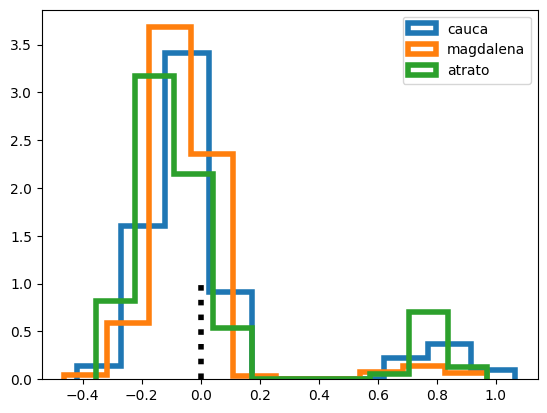

In [100]:
basin=pd.get_dummies(db['CUENCA_GRA'])
cauca=m1.u[basin["Cauca"]]
magdalena=m1.u[basin["Magdalena"]]
atrato=m1.u[basin["Atrato"]]
plt.hist(cauca, histtype='step', density=True, linewidth=4, label='cauca')
plt.hist(magdalena, histtype='step', density=True, linewidth=4, label='magdalena')
plt.hist(atrato, histtype='step', density=True, linewidth=4, label='atrato')
plt.vlines(0,0,1, linestyle=":", color='k', linewidth=4)
plt.legend()
plt.show()

In [101]:
stats.ttest_ind(cauca,magdalena)

TtestResult(statistic=array([5.88799168]), pvalue=array([4.19811672e-09]), df=array([4431.]))

In [102]:
stats.ttest_ind(cauca,atrato)

TtestResult(statistic=array([2.23856638]), pvalue=array([0.02523222]), df=array([4559.]))

In [103]:
stats.ttest_ind(atrato,magdalena)

TtestResult(statistic=array([3.07351508]), pvalue=array([0.00213944]), df=array([2388.]))

## Logistic regression

In [104]:
from spglm.glm import GLM
from spglm.family import Binomial

In [120]:
model = smf.logit(formula = "MenM ~ Pendiente + C(Cobertura) + C(Nombre_3)", data = db).fit()
print(model.summary())

         Current function value: 0.252734
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                   MenM   No. Observations:                 6189
Model:                          Logit   Df Residuals:                     6175
Method:                           MLE   Df Model:                           13
Date:                Fri, 16 Feb 2024   Pseudo R-squ.:                  0.1707
Time:                        19:36:22   Log-Likelihood:                -1564.2
converged:                      False   LL-Null:                       -1886.2
Covariance Type:            nonrobust   LLR p-value:                2.971e-129
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                 -32.2243   2.16e+06  -1.49e-05      1.000   

In [124]:
model.resid

AttributeError: 'LogitResults' object has no attribute 'resid'